# Customer Churn Analysis and Prediction

## Project Overview

This project analyses customer churn data to identify patterns associated with customer attrition and develops machine learning models to predict customers who may leave.

The analysis includes data cleaning, exploratory data analysis, statistical analysis and hypothesis testing, customer churn prediction, model evaluation, and comparison of Logistic Regression and Random Forest models.

## Project Objectives

The aim of this project is to analyse customer churn in a credit card customer dataset and identify factors that are associated with customer attrition.

The project will:

* Explore customer demographics, account activity and transaction behaviour.
* Clean and prepare the dataset for analysis and machine learning.
* Investigate patterns and relationships between customer characteristics and churn.
* Use statistical analysis and hypothesis testing to examine differences between existing and attrited customers.
* Develop and compare supervised machine learning models to predict customer churn.
* Evaluate model performance using accuracy, precision, recall, F1-score and ROC-AUC.
* Identify the customer and account characteristics that are most important to the prediction model.
* Provide data-driven insights that could support customer retention strategies.


In [1]:
print("Customer Churn project is ready")

Customer Churn project is ready


## Analytical Questions

The analysis will address the following questions:

1. What customer characteristics and behaviours are associated with higher levels of churn?

2. Are there noticeable differences in transaction activity between existing and attrited customers?

3. Is there a statistically significant difference in transaction frequency between existing and attrited customers?

4. Which customer, account and transaction features are most important when predicting customer churn?

5. How effectively can machine learning models predict whether a customer is likely to churn?

6. Which of the selected machine learning models provides stronger predictive performance based on the evaluation metrics used?


## 1. Data Understanding

In [2]:
import pandas as pd

# Load the customer churn dataset
df = pd.read_csv("BankChurners.csv")

# Display the first 5 rows
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
df.shape

(10127, 23)

In [4]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [8]:
df['Attrition_Flag'].value_counts(normalize=True) * 100

Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64

In [9]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Attrition_Flag
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Gender
Gender
F    5358
M    4769
Name: count, dtype: int64

Education_Level
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

Marital_Status
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

Income_Category
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

Card_Category
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64


In [10]:
id="p4zq7n"
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


## 2. Data Cleaning and Preparation

In [11]:
df_clean = df.copy()

In [12]:
df_clean = df_clean.drop(columns=['CLIENTNUM'])

In [13]:
df_clean = df_clean.drop(columns=[
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

In [14]:
df_clean.shape

(10127, 20)

In [15]:
df_clean.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [16]:
for column in ['Education_Level', 'Marital_Status', 'Income_Category']:
    print(f"{column}: {df_clean[column].eq('Unknown').sum()} Unknown values")

Education_Level: 1519 Unknown values
Marital_Status: 749 Unknown values
Income_Category: 1112 Unknown values


In [17]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000,2.000,3.000,5.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.219207,0.0,0.631,0.736,0.859,3.397


## 3. Exploratory Data Analysis

In [18]:
pd.crosstab(
    df_clean['Gender'],
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Gender,,
F,17.357223,82.642777
M,14.615223,85.384777


In [19]:
pd.crosstab(
    df_clean['Income_Category'],
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Income_Category,,
$120K +,17.331499,82.668501
$40K - $60K,15.139665,84.860335
$60K - $80K,13.480742,86.519258
$80K - $120K,15.765472,84.234528
Less than $40K,17.186184,82.813816
Unknown,16.816547,83.183453


In [20]:
pd.crosstab(
    df_clean['Months_Inactive_12_mon'],
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Months_Inactive_12_mon,,
0,51.724138,48.275862
1,4.478280,95.521720
2,15.386959,84.613041
3,21.476859,78.523141
4,29.885057,70.114943
5,17.977528,82.022472
6,15.322581,84.677419


In [21]:
pd.crosstab(
    df_clean['Contacts_Count_12_mon'],
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Contacts_Count_12_mon,,
0,1.754386,98.245614
1,7.204803,92.795197
2,12.488379,87.511621
3,20.147929,79.852071
4,22.629310,77.370690
5,33.522727,66.477273
6,100.000000,0.000000


In [22]:
pd.qcut(
    df_clean['Total_Trans_Ct'],
    q=4,
    duplicates='drop'
).groupby(df_clean['Attrition_Flag']).value_counts()

Attrition_Flag     Total_Trans_Ct
Attrited Customer  (9.999, 45.0]      968
                   (45.0, 67.0]       514
                   (67.0, 81.0]       119
                   (81.0, 139.0]       26
Existing Customer  (67.0, 81.0]      2543
                   (81.0, 139.0]     2316
                   (45.0, 67.0]      1998
                   (9.999, 45.0]     1643
Name: count, dtype: int64

In [23]:
transaction_groups = pd.qcut(
    df_clean['Total_Trans_Ct'],
    q=4,
    duplicates='drop'
)

pd.crosstab(
    transaction_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Total_Trans_Ct,,
"(9.999, 45.0]",37.073918,62.926082
"(45.0, 67.0]",20.461783,79.538217
"(67.0, 81.0]",4.470323,95.529677
"(81.0, 139.0]",1.110162,98.889838


In [24]:
pd.qcut(
    df_clean['Total_Trans_Amt'],
    q=4
).groupby(df_clean['Attrition_Flag']).value_counts()

Attrition_Flag     Total_Trans_Amt  
Attrited Customer  (2155.5, 3899.0]      697
                   (509.999, 2155.5]     618
                   (4741.0, 18484.0]     290
                   (3899.0, 4741.0]       22
Existing Customer  (3899.0, 4741.0]     2512
                   (4741.0, 18484.0]    2239
                   (509.999, 2155.5]    1914
                   (2155.5, 3899.0]     1835
Name: count, dtype: int64

In [25]:
transaction_amount_groups = pd.qcut(
    df_clean['Total_Trans_Amt'],
    q=4
)

pd.crosstab(
    transaction_amount_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Total_Trans_Amt,,
"(509.999, 2155.5]",24.407583,75.592417
"(2155.5, 3899.0]",27.527646,72.472354
"(3899.0, 4741.0]",0.868193,99.131807
"(4741.0, 18484.0]",11.466983,88.533017


In [26]:
pd.crosstab(
    df_clean['Card_Category'],
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Card_Category,,
Blue,16.097923,83.902077
Gold,18.103448,81.896552
Platinum,25.000000,75.000000
Silver,14.774775,85.225225


In [27]:
age_groups = pd.qcut(
    df_clean['Customer_Age'],
    q=4
)

pd.crosstab(
    age_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Customer_Age,,
"(25.999, 41.0]",15.057637,84.942363
"(41.0, 46.0]",16.505263,83.494737
"(46.0, 52.0]",15.980539,84.019461
"(52.0, 73.0]",16.927083,83.072917


In [28]:
pd.crosstab(
    df_clean['Total_Relationship_Count'],
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Total_Relationship_Count,,
1,25.604396,74.395604
2,27.835881,72.164119
3,17.353579,82.646421
4,11.767782,88.232218
5,12.004231,87.995769
6,10.503751,89.496249


In [29]:
revolving_balance_groups = pd.qcut(
    df_clean['Total_Revolving_Bal'],
    q=4,
    duplicates='drop'
)

pd.crosstab(
    revolving_balance_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Total_Revolving_Bal,,
"(-0.001, 359.0]",37.717220,62.282780
"(359.0, 1276.0]",10.308057,89.691943
"(1276.0, 1784.0]",4.339250,95.660750
"(1784.0, 2517.0]",11.906646,88.093354


In [30]:
utilization_groups = pd.qcut(
    df_clean['Avg_Utilization_Ratio'],
    q=4,
    duplicates='drop'
)

pd.crosstab(
    utilization_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Avg_Utilization_Ratio,,
"(-0.001, 0.023]",36.599764,63.400236
"(0.023, 0.176]",9.292210,90.707790
"(0.176, 0.503]",9.371293,90.628707
"(0.503, 0.999]",8.900316,91.099684


In [31]:
credit_limit_groups = pd.qcut(
    df_clean['Credit_Limit'],
    q=4,
    duplicates='drop'
)

pd.crosstab(
    credit_limit_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Credit_Limit,,
"(1438.299, 2555.0]",20.394477,79.605523
"(2555.0, 4549.0]",13.986567,86.013433
"(4549.0, 11067.5]",15.302491,84.697509
"(11067.5, 34516.0]",14.573460,85.426540


In [32]:
months_on_book_groups = pd.qcut(
    df_clean['Months_on_book'],
    q=4,
    duplicates='drop'
)

pd.crosstab(
    months_on_book_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

Attrition_Flag,Attrited Customer,Existing Customer
Months_on_book,,
"(12.999, 31.0]",14.696612,85.303388
"(31.0, 36.0]",16.742688,83.257312
"(36.0, 40.0]",16.533720,83.466280
"(40.0, 56.0]",16.190093,83.809907


NameError: name 'plt' is not defined

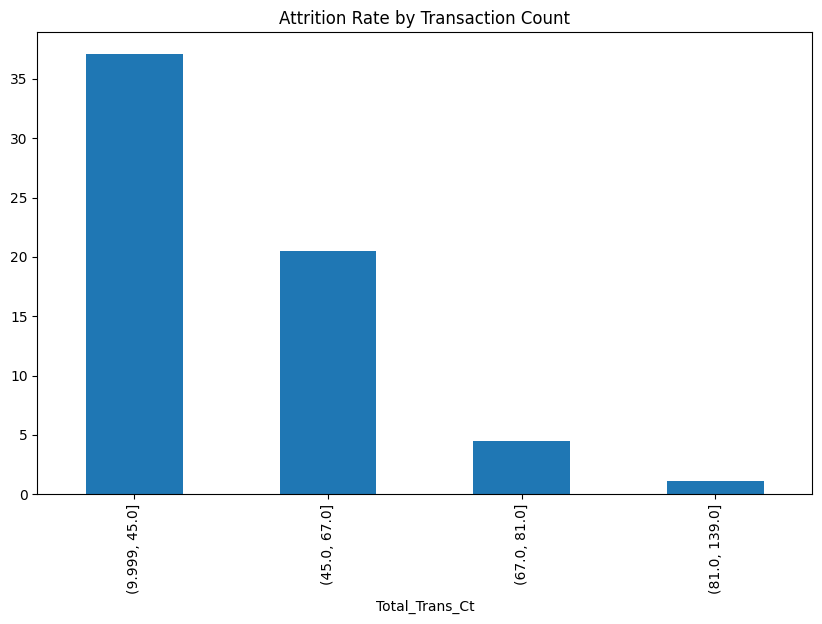

In [33]:
transaction_attrition = pd.crosstab(
    transaction_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

transaction_attrition['Attrited Customer'].plot(
    kind='bar',
    figsize=(10, 6),
    title='Attrition Rate by Transaction Count'
)

plt.xlabel('Total Transaction Count')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
import matplotlib.pyplot as plt


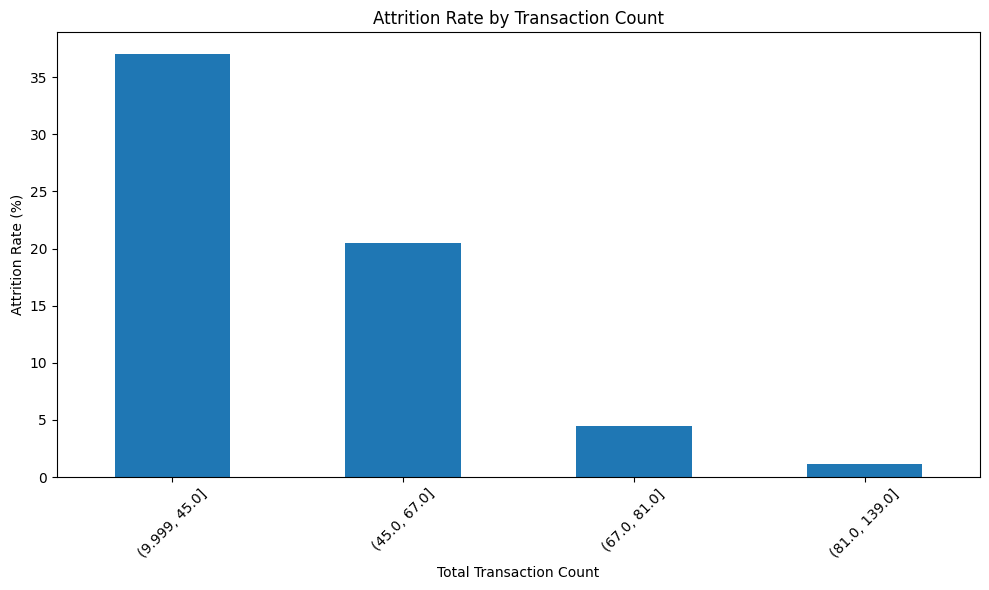

In [35]:
transaction_attrition = pd.crosstab(
    transaction_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

transaction_attrition['Attrited Customer'].plot(
    kind='bar',
    figsize=(10, 6),
    title='Attrition Rate by Transaction Count'
)

plt.xlabel('Total Transaction Count')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

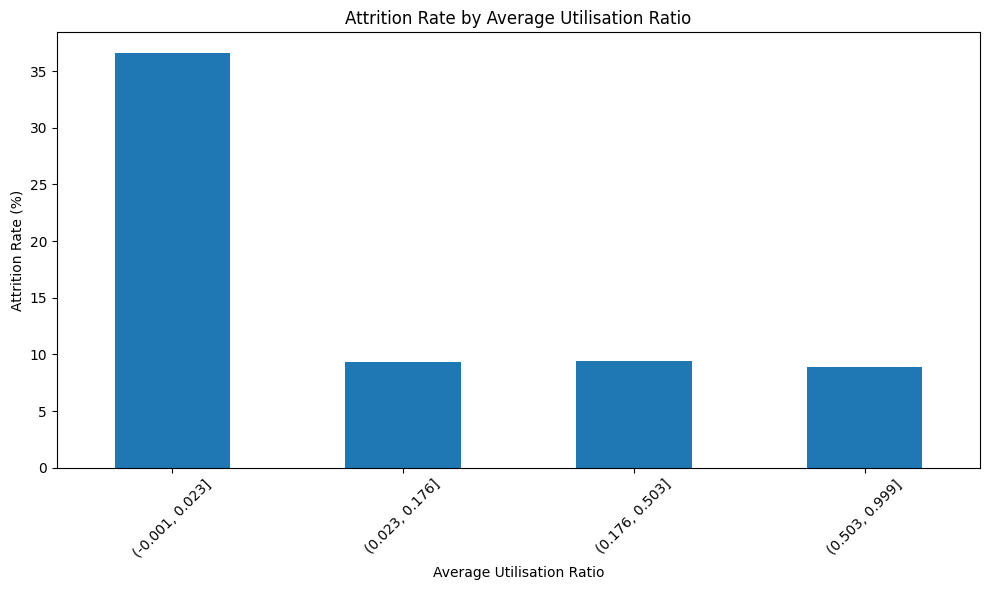

In [36]:
utilization_attrition = pd.crosstab(
    utilization_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

utilization_attrition['Attrited Customer'].plot(
    kind='bar',
    figsize=(10, 6),
    title='Attrition Rate by Average Utilisation Ratio'
)

plt.xlabel('Average Utilisation Ratio')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

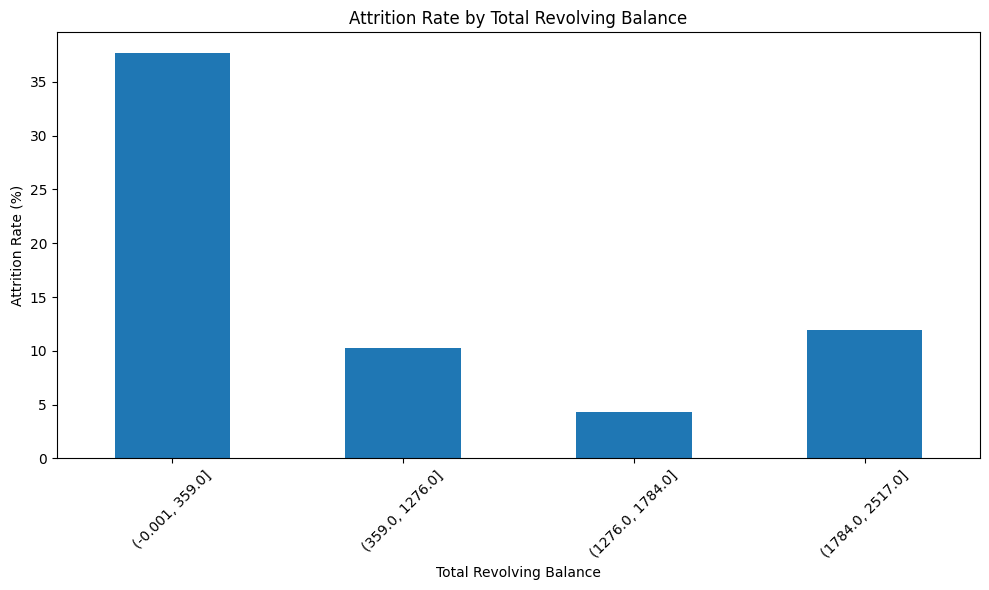

In [37]:
revolving_attrition = pd.crosstab(
    revolving_balance_groups,
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

revolving_attrition['Attrited Customer'].plot(
    kind='bar',
    figsize=(10, 6),
    title='Attrition Rate by Total Revolving Balance'
)

plt.xlabel('Total Revolving Balance')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

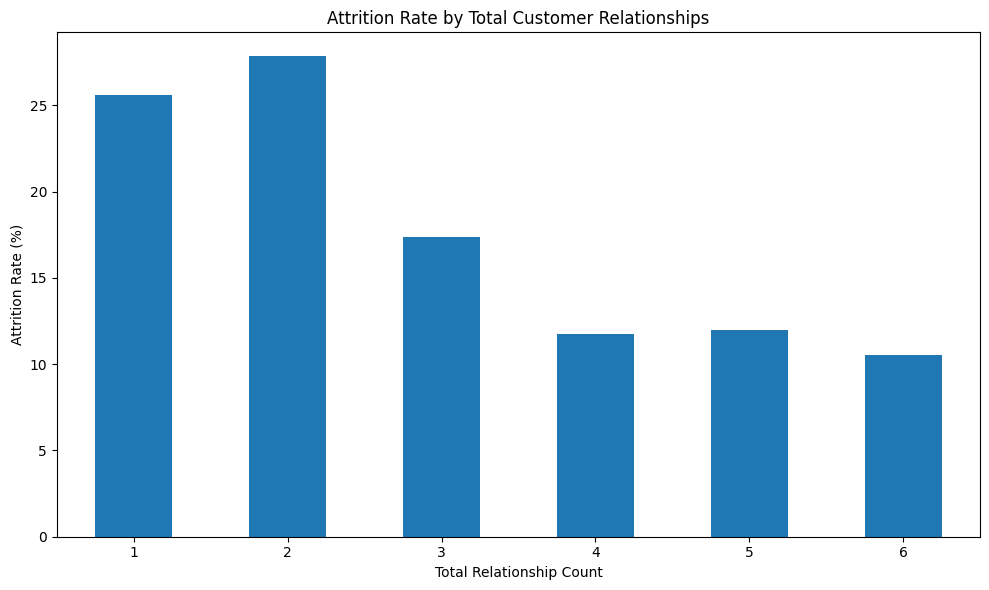

In [38]:
relationship_attrition = pd.crosstab(
    df_clean['Total_Relationship_Count'],
    df_clean['Attrition_Flag'],
    normalize='index'
) * 100

relationship_attrition['Attrited Customer'].plot(
    kind='bar',
    figsize=(10, 6),
    title='Attrition Rate by Total Customer Relationships'
)

plt.xlabel('Total Relationship Count')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Statistical Analysis and Hypothesis Testing

### Statistical Concepts

Statistics provides methods for collecting, summarising and interpreting data. In this project, descriptive statistics are used to understand customer transaction behaviour, while hypothesis testing is used to determine whether observed differences between customer groups are statistically significant.

**Mean:** The mean is the average value of a numerical variable. It is calculated by adding all values and dividing by the number of observations. In this project, the mean is used to understand the average transaction count.

**Median:** The median is the middle value when observations are arranged in order. It is useful for understanding the centre of the data and can be less affected by extreme values than the mean.

**Variance:** Variance measures how widely observations are spread around the mean. A higher variance indicates greater variability in the data.

**Standard Deviation:** Standard deviation measures the typical spread of observations around the mean. It is easier to interpret than variance because it is expressed in the same units as the original variable.

**Hypothesis Testing:** Hypothesis testing provides a statistical method for assessing whether there is sufficient evidence of a difference or relationship in the data. In this project, a Welch's independent samples t-test is used to compare the mean transaction counts of existing and attrited customers.

**Probability:** Probability measures the likelihood of an event occurring. In a churn analysis, probabilities can help describe the likelihood of customers belonging to different outcomes, such as remaining with or leaving the company.

These statistical methods provide a foundation for understanding the dataset before applying machine learning models to predict customer churn.


In [77]:
df_clean['Churn'] = df_clean['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

df_clean[['Attrition_Flag', 'Churn']].head()

,Attrition_Flag,Churn
0,Existing Customer,0
1,Existing Customer,0
2,Existing Customer,0
3,Existing Customer,0
4,Existing Customer,0


In [78]:
# Descriptive statistics for transaction count
print("Mean transaction count:", df_clean['Total_Trans_Ct'].mean())
print("Median transaction count:", df_clean['Total_Trans_Ct'].median())
print("Variance of transaction count:", df_clean['Total_Trans_Ct'].var())
print("Standard deviation of transaction count:", df_clean['Total_Trans_Ct'].std())

Mean transaction count: 64.85869457884863
Median transaction count: 67.0
Variance of transaction count: 550.9615634942062
Standard deviation of transaction count: 23.472570449232997


### Hypothesis

The hypothesis tests whether the mean transaction count differs between existing and attrited customers.

**Null Hypothesis (H₀):** There is no statistically significant difference in the mean transaction count between existing customers and attrited customers.

**Alternative Hypothesis (H₁):** There is a statistically significant difference in the mean transaction count between existing customers and attrited customers.

A significance level of **0.05** is used. If the p-value is below 0.05, the null hypothesis will be rejected in favour of the alternative hypothesis.


In [76]:
from scipy.stats import ttest_ind

# Separate transaction counts for existing and attrited customers
existing_transactions = df_clean.loc[
    df_clean['Churn'] == 0, 'Total_Trans_Ct'
]

attrited_transactions = df_clean.loc[
    df_clean['Churn'] == 1, 'Total_Trans_Ct'
]

# Perform Welch's independent samples t-test
t_stat, p_value = ttest_ind(
    existing_transactions,
    attrited_transactions,
    equal_var=False
)

print("Existing customers mean transaction count:", existing_transactions.mean())
print("Attrited customers mean transaction count:", attrited_transactions.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

Existing customers mean transaction count: 68.67258823529411
Attrited customers mean transaction count: 44.93362015980332
t-statistic: 54.141872509434684
p-value: 0.0


### Hypothesis Test Interpretation

The Welch's independent samples t-test produced a t-statistic of approximately **54.14** and a p-value displayed as **0.0**, indicating that the p-value is extremely small.

Because the p-value is below the significance level of 0.05, the null hypothesis is rejected. There is statistically significant evidence of a difference in mean transaction count between existing and attrited customers in this dataset.

Existing customers had an average transaction count of approximately **68.67**, compared with approximately **44.93** for attrited customers.

This result indicates a strong association between transaction activity and customer churn in the dataset. However, statistical significance does not establish that lower transaction activity causes customers to churn. Other customer and account characteristics may also contribute to the observed relationship.


### Machine Learning Methodology

This project uses supervised machine learning because the target variable, customer churn, is known for each customer in the dataset. The task is therefore a binary classification problem, where customers are classified as either existing customers or attrited customers.

Two classification algorithms were selected: **Logistic Regression** and **Random Forest**.

**Logistic Regression** was selected as a baseline classification model because it is suitable for binary outcomes and provides interpretable coefficients that can help identify how individual features are associated with the predicted churn outcome.

**Random Forest** was selected as a second approach because it can capture non-linear relationships and interactions between features. It combines multiple decision trees and can also provide feature importance information, which is useful for identifying variables that contribute most to the model's predictions.

Using two different approaches allows their predictive performance to be compared using accuracy, precision, recall, F1-score and ROC-AUC. This provides a more balanced assessment than relying on a single evaluation metric.


## 5. Machine Learning Preparation

In [39]:
df_clean['Churn'] = df_clean['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

df_clean[['Attrition_Flag', 'Churn']].head()

,Attrition_Flag,Churn
0,Existing Customer,0
1,Existing Customer,0
2,Existing Customer,0
3,Existing Customer,0
4,Existing Customer,0


In [40]:
df_clean['Churn'].isna().sum()

np.int64(0)

In [41]:
X = df_clean.drop(columns=['Attrition_Flag', 'Churn'])
y = df_clean['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10127, 19)
y shape: (10127,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8101, 19)
X_test shape: (2026, 19)
y_train shape: (8101,)
y_test shape: (2026,)


In [43]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

Numerical features:
['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


### Machine Learning Data Preparation

Before training the models, the dataset was prepared to ensure that the input variables were suitable for machine learning.

The `CLIENTNUM` column was removed because it is a customer identifier and does not provide meaningful predictive information.

The two Naive Bayes classifier columns were also removed because they contain model-generated information related to the attrition outcome. Keeping these variables could introduce data leakage and result in misleading model performance.

The target variable was converted into a binary `Churn` variable, where existing customers were assigned 0 and attrited customers were assigned 1.

The categorical variables were transformed using one-hot encoding, while numerical variables were standardised using `StandardScaler`. The preprocessing transformer was fitted only on the training data and then applied to the test data to reduce the risk of data leakage.

The dataset was divided into training and testing sets using an 80:20 split. Stratified sampling was used to maintain a similar proportion of existing and attrited customers in both datasets.


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (8101, 37)
Processed X_test shape: (2026, 37)


### Model Evaluation Metrics

The machine learning models were evaluated using several performance metrics because no single metric provides a complete assessment of a churn classification model.

**Accuracy** measures the proportion of all predictions that are correct. However, accuracy alone can be misleading when the target classes are imbalanced, as is the case in this dataset where existing customers are more numerous than attrited customers.

**Precision** measures the proportion of customers predicted as attrited who were actually attrited. A higher precision means fewer existing customers are incorrectly identified as likely to churn.

**Recall** measures the proportion of actual attrited customers that the model correctly identifies. Recall is particularly important in churn analysis because failing to identify a customer who is likely to leave may mean a missed opportunity for customer retention.

**F1-score** combines precision and recall into a single measure and is useful when both types of performance are important.

**ROC-AUC** measures the model's ability to distinguish between existing and attrited customers across different classification thresholds. A value closer to 1 indicates stronger discriminatory performance.

Using these metrics together provides a more balanced assessment of how effectively the models identify potential churners.


## 6. Model Training and Evaluation

### Model Evaluation Metrics

The machine learning models were evaluated using several performance metrics because no single metric provides a complete assessment of a churn classification model.

**Accuracy** measures the proportion of all predictions that are correct. However, accuracy alone can be misleading when the target classes are imbalanced, as is the case in this dataset where existing customers are more numerous than attrited customers.

**Precision** measures the proportion of customers predicted as attrited who were actually attrited. A higher precision means fewer existing customers are incorrectly identified as likely to churn.

**Recall** measures the proportion of actual attrited customers that the model correctly identifies. Recall is particularly important in churn analysis because failing to identify a customer who is likely to leave may mean a missed opportunity for customer retention.

**F1-score** combines precision and recall into a single measure and is useful when both types of performance are important.

**ROC-AUC** measures the model's ability to distinguish between existing and attrited customers across different classification thresholds. A value closer to 1 indicates stronger discriminatory performance.

Using these metrics together provides a more balanced assessment of how effectively the models identify potential churners.


In [45]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [46]:
y_pred = logistic_model.predict(X_test_processed)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8998025666337611
Precision: 0.7675438596491229
Recall: 0.5384615384615384
F1 Score: 0.6329113924050633

Confusion Matrix:
[[1648   53]
 [ 150  175]]


In [48]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [50]:
y_pred_rf = random_forest_model.predict(X_test_processed)

print("First 20 Random Forest predictions:")
print(y_pred_rf[:20])

First 20 Random Forest predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest Precision:", precision_rf)
print("Random Forest Recall:", recall_rf)
print("Random Forest F1 Score:", f1_rf)

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9545903257650543
Random Forest Precision: 0.8584615384615385
Random Forest Recall: 0.8584615384615385
Random Forest F1 Score: 0.8584615384615385

Random Forest Confusion Matrix:
[[1655   46]
 [  46  279]]


In [52]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Existing Customer', 'Attrited Customer']
))

Random Forest Classification Report:
                   precision    recall  f1-score   support

Existing Customer       0.97      0.97      0.97      1701
Attrited Customer       0.86      0.86      0.86       325

         accuracy                           0.95      2026
        macro avg       0.92      0.92      0.92      2026
     weighted avg       0.95      0.95      0.95      2026



In [53]:
from sklearn.metrics import roc_auc_score

y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.9845529778863111


### Model Performance Interpretation

The two models produced different levels of predictive performance.

Logistic Regression achieved an accuracy of **89.98%**, precision of **76.75%**, recall of **53.85%**, F1-score of **63.29%**, and ROC-AUC of **91.67%**. Although the model identified many customers correctly overall, its recall indicates that it did not identify all of the customers who actually churned.

Random Forest achieved an accuracy of **95.46%**, precision of **85.85%**, recall of **85.85%**, F1-score of **85.85%**, and ROC-AUC of **98.46%**. Its higher recall indicates that it identified a larger proportion of the actual attrited customers, while its precision indicates fewer incorrect churn predictions.

The results show that the Random Forest model performed more strongly across the evaluation metrics used in this project. Its ability to capture non-linear relationships and interactions between variables may have contributed to the observed difference in performance.

However, these results should be interpreted within the limitations of the dataset and modelling approach. Performance on this dataset does not guarantee the same performance on new customer populations or future data. Further validation and threshold analysis could be considered before using the model in a real-world customer retention system.


In [54]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                          Feature  Importance
10           num__Total_Trans_Amt    0.200375
11            num__Total_Trans_Ct    0.189512
7        num__Total_Revolving_Bal    0.111840
12       num__Total_Ct_Chng_Q4_Q1    0.097945
13     num__Avg_Utilization_Ratio    0.062523
9       num__Total_Amt_Chng_Q4_Q1    0.060352
3   num__Total_Relationship_Count    0.045682
8            num__Avg_Open_To_Buy    0.031217
4     num__Months_Inactive_12_mon    0.030040
6               num__Credit_Limit    0.029843
0               num__Customer_Age    0.027378
5      num__Contacts_Count_12_mon    0.024708
2             num__Months_on_book    0.021160
1            num__Dependent_count    0.010677
15                  cat__Gender_M    0.005372


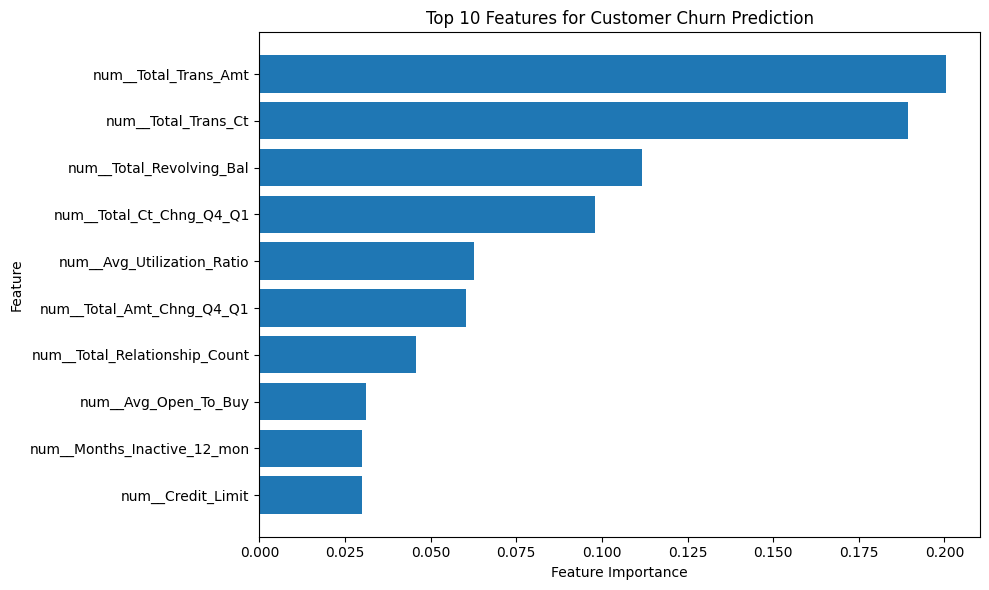

In [55]:
top_features = feature_importance.head(10).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Features for Customer Churn Prediction')

plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The Random Forest feature-importance analysis identified several variables that contributed strongly to the model's predictions of customer churn.

The most important features included **Total Transaction Amount**, **Total Transaction Count**, **Total Revolving Balance**, **Total Change in Transaction Count**, and **Average Utilisation Ratio**.

Transaction-related variables were particularly prominent in the model. This suggests that customer activity and engagement patterns contain useful information for distinguishing between existing and attrited customers.

The importance of transaction count is consistent with the earlier exploratory analysis and hypothesis test, which showed that attrited customers had a substantially lower average transaction count than existing customers.

However, feature importance indicates how useful a variable was to the model's predictions; it does not demonstrate that the feature causes customer churn. The findings should therefore be interpreted as predictive associations rather than causal relationships.


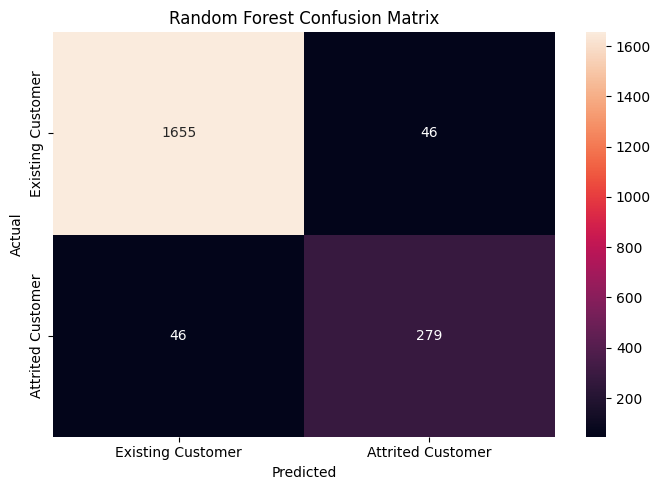

In [60]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
cmap='Greens',
sns.heatmap(
    cm,
    annot=True,
    fmt='d',

    xticklabels=['Existing Customer', 'Attrited Customer'],
    yticklabels=['Existing Customer', 'Attrited Customer']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

## 7. Model Comparison

In [61]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_rf],
    'Precision': [precision, precision_rf],
    'Recall': [recall, recall_rf],
    'F1 Score': [f1, f1_rf]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.899803,0.767544,0.538462,0.632911
1,Random Forest,0.954590,0.858462,0.858462,0.858462


### Model Comparison Interpretation

The model comparison shows that Random Forest achieved stronger performance than Logistic Regression across all evaluation metrics used in this project.

Random Forest achieved higher **accuracy, precision, recall, F1-score and ROC-AUC** than Logistic Regression. In particular, the higher recall indicates that Random Forest identified a greater proportion of customers who actually churned.

Logistic Regression remains useful as a baseline model because its coefficients provide an interpretable indication of how individual features are associated with the prediction. Random Forest can capture more complex and non-linear relationships between customer characteristics and churn.

The comparison demonstrates why evaluating more than one modelling approach is important. Different algorithms can produce different results, so model selection should consider several performance measures rather than accuracy alone.

For this project, the models were evaluated using the same test dataset to provide a consistent basis for comparison. However, further validation would be required before applying either model to a real-world customer retention system.


In [62]:
model_comparison.to_csv(
    'model_comparison_results.csv',
    index=False
)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.


In [63]:
from sklearn.metrics import roc_auc_score

y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression ROC-AUC:", roc_auc_logistic)

Logistic Regression ROC-AUC: 0.9167204811649257


In [64]:
model_comparison['ROC-AUC'] = [
    roc_auc_logistic,
    roc_auc_rf
]

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.899803,0.767544,0.538462,0.632911,0.916720
1,Random Forest,0.954590,0.858462,0.858462,0.858462,0.984553


In [65]:
model_comparison.to_csv(
    'model_comparison_results.csv',
    index=False
)

print("Updated model comparison results saved successfully.")

Updated model comparison results saved successfully.


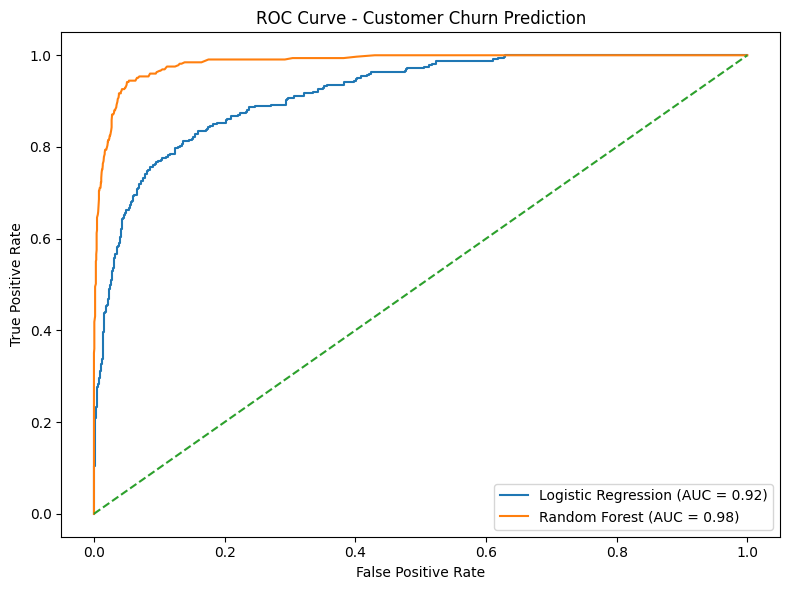

In [66]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve values
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Create the ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f'Logistic Regression (AUC = {roc_auc_logistic:.2f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_rf:.2f})'
)

# Reference line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Customer Churn Prediction')
plt.legend()

plt.tight_layout()
plt.show()

In [67]:
logistic_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': logistic_model.coef_[0]
})

logistic_coefficients['Absolute_Coefficient'] = (
    logistic_coefficients['Coefficient'].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

logistic_coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
11,num__Total_Trans_Ct,-2.745251,2.745251
10,num__Total_Trans_Amt,1.563652,1.563652
15,cat__Gender_M,-0.901693,0.901693
33,cat__Card_Category_Blue,-0.794664,0.794664
3,num__Total_Relationship_Count,-0.741036,0.741036
7,num__Total_Revolving_Bal,-0.724755,0.724755
12,num__Total_Ct_Chng_Q4_Q1,-0.671673,0.671673
24,cat__Marital_Status_Married,-0.610602,0.610602
5,num__Contacts_Count_12_mon,0.570670,0.570670
4,num__Months_Inactive_12_mon,0.519362,0.519362


## 7. Visualisations and Feature Analysis

In [68]:
logistic_coefficients.to_csv(
    'logistic_regression_coefficients.csv',
    index=False
)

print("Logistic Regression coefficients saved successfully.")

Logistic Regression coefficients saved successfully.
